# Task 023
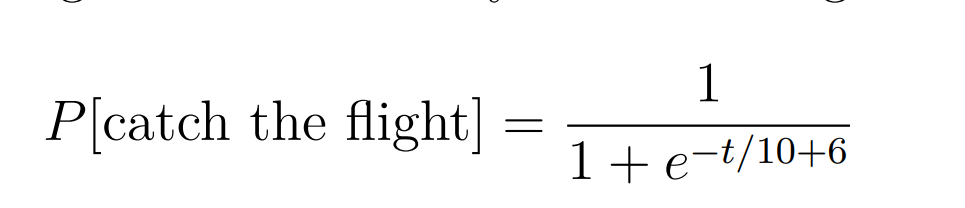

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def p_catch(t):
    """Berechnet die Wahrscheinlichkeit, einen Anschlussflug bei einer Zeit t zu erreichen."""
    return 1 / (1 + np.exp(-t / 10 + 6))

def simuflight():
    """
    Simuliert eine Reise mit zwei Anschlussflügen für einen einzelnen Passagier.
    Gibt 1 bei Erfolg (beide Flüge erreicht) und 0 bei Misserfolg zurück.
    """
    # a) Generierung der normalverteilten Anschlusszeiten t1 und t2
    # np.random.normal(loc=mu, scale=sigma) wird hier verwendet
    t1 = np.random.normal(loc=115, scale=45)
    t2 = np.random.normal(loc=70, scale=25)
    
    # Berechne die Wahrscheinlichkeiten für beide Flüge
    p1 = p_catch(t1)
    p2 = p_catch(t2)
    
    # Simuliere, ob der Passagier den jeweiligen Flug tatsächlich erwischt
    # Ein zufälliger Wert zwischen 0 und 1 entscheidet anhand der Wahrscheinlichkeit
    success_1 = np.random.rand() < p1
    success_2 = np.random.rand() < p2
    
    # Erfolg nur, wenn BEIDE Anschlussflüge erreicht wurden
    if success_1 and success_2:
        return 1
    else:
        return 0

def control():
    """
    b) & c) Führt die Simulation n-mal aus, berechnet den Schätzer 
    und das 95%-Konfidenzintervall.
    """
    # Eine ausreichend große Anzahl an Simulationen für stabile Ergebnisse
    n = 100000  
    
    # Führe die Simulation n-mal aus
    results = np.array([simuflight() for _ in range(n)])
    
    # b) Berechne den Punktschätzer für die Gesamterfolgwahrscheinlichkeit
    p_hat = np.mean(results)
    
    # c) Berechnung des 95%-Konfidenzintervalls
    confidence_level = 0.95
    z_alpha_2 = stats.norm.ppf(1 - (1 - confidence_level) / 2) # ca. 1.96
    
    # Standardfehler für einen Anteilswert (Proportion)
    standard_error = np.sqrt((p_hat * (1 - p_hat)) / n)
    
    # Margenfehler (Margin of Error)
    margin_of_error = z_alpha_2 * standard_error
    
    lower_bound = p_hat - margin_of_error
    upper_bound = p_hat + margin_of_error
    
    # Ausgabe in der Konsole
    print(f"Anzahl der Simulationen (n): {n:,}")
    print(f"Geschätzte Gesamterfolgwahrscheinlichkeit (p_hat): {p_hat:.4f} ({p_hat * 100:.2f}%)")
    print(f"95%-Konfidenzintervall: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Ausführen des Programms
if __name__ == "__main__":
    control()

Anzahl der Simulationen (n): 100,000
Geschätzte Gesamterfolgwahrscheinlichkeit (p_hat): 0.5464 (54.63%)
95%-Konfidenzintervall: [0.5433, 0.5494]


# Task 024
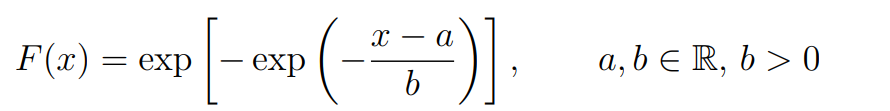

Wir lösen Schritt für Schritt nach $x$ auf ($r \in (0, 1)$):Logarithmieren:$$\ln(r) = -\exp \left( -\frac{x - a}{b} \right)$$Mit $-1$ multiplizieren:$$-\ln(r) = \exp \left( -\frac{x - a}{b} \right)$$Erneut logarithmieren:$$\ln(-\ln(r)) = -\frac{x - a}{b}$$Mit $-b$ multiplizieren und $a$ addieren:$$x = a - b \cdot \ln(-\ln(r))$$Die gesuchte Umkehrfunktion lautet somit:$$F^{-1}(r) = a - b \cdot \ln(-\ln(r))$$

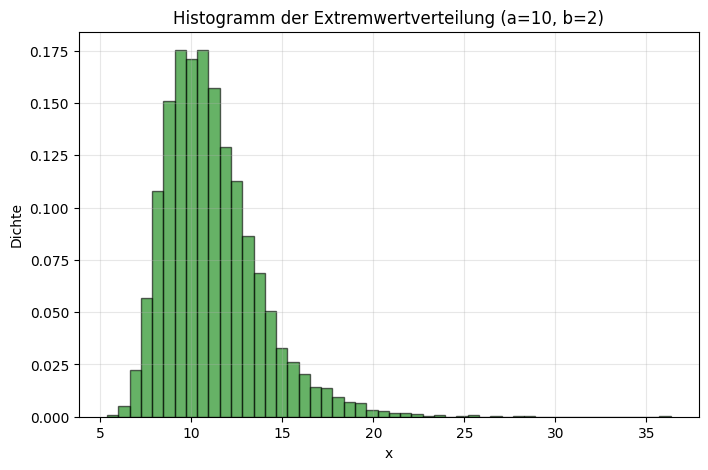

In [5]:
def myev(a, b):
    """Generiert eine Pseudozufallszahl der Extremwertverteilung."""
    r = np.random.rand()
    # Vermeidung von r=0 oder r=1 wegen des Logarithmus
    while r == 0 or r == 1:
        r = np.random.rand()
    return a - b * np.log(-np.log(r))

# Generierung von Testdaten für den Plot
a, b = 10, 2
data = [myev(a, b) for _ in range(10000)]

# Histogramm erstellen
plt.figure(figsize=(8, 5))
plt.hist(data, bins=50, density=True, alpha=0.6, color='g', edgecolor='black')
plt.title(f'Histogramm der Extremwertverteilung (a={a}, b={b})')
plt.xlabel('x')
plt.ylabel('Dichte')
plt.grid(True, alpha=0.3)
plt.show()

## Teil b) Simulation eines Jahres
Ein Jahr besteht aus 12 Monaten. Wir berechnen für die 12 gezogenen Werte den Mittelwert und prüfen die Bedingung.

In [6]:
def simu():
    """Simuliert ein Jahr und gibt 1 (gut) oder 0 (schlecht) zurück."""
    # 12 monatliche Maximalwerte ziehen (mit a=10, b=2)
    months = np.array([myev(10, 2) for _ in range(12)])
    
    # Jährlichen Mittelwert berechnen
    yearly_mean = np.mean(months)
    
    # Anzahl der Monate zählen, die kleiner als der Mittelwert sind
    count_smaller = np.sum(months < yearly_mean)
    
    # Klassifikation: Wenn >= 6 Monate kleiner sind -> "bad" (0), sonst "good" (1)
    if count_smaller >= 6:
        return 0
    else:
        return 1

## Teil c) Bestimmung des Stichprobenumfangs n & Steuerungsskript
Wir schätzen den Anteil $p$ der "guten" Jahre. Dies entspricht einem Experiment mit einer Bernoulli-Verteilung.Für die Bestimmung des Stichprobenumfangs $n$ bei einem $95\%$-Konfidenzintervall mit einer maximalen Abweichung (Fehlermarge) von $E = \pm 0{,}05$ nutzen wir den konservativen Ansatz (Worst-Case, bei dem die Varianz mit $p = 0{,}5$ maximal wird).

Das Quantil der Standardnormalverteilung für ein $95\%$-Konfidenzintervall ist $z_{1-\alpha/2} = z_{0{,}975} \approx 1{,}96$.

In [10]:
def control():
    """Führt die Simulation n-mal aus und gibt den Anteil guter Jahre aus."""
    # Berechnetes minimales n = 385 (wir nutzen hier z.B. 20000 für exaktere Werte)
    n = 20000 
    
    results = [simu() for _ in range(n)]
    
    # Anteil der "1"-en (gute Jahre) berechnen
    percentage_good = (np.sum(results) / n) * 100
    
    print(f"Stichprobenumfang (n): {n}")
    print(f"Prozentsatz der 'guten' Jahre: {percentage_good:.2f}%")

# Skript ausführen
control()

Stichprobenumfang (n): 20000
Prozentsatz der 'guten' Jahre: 12.05%


# Task025
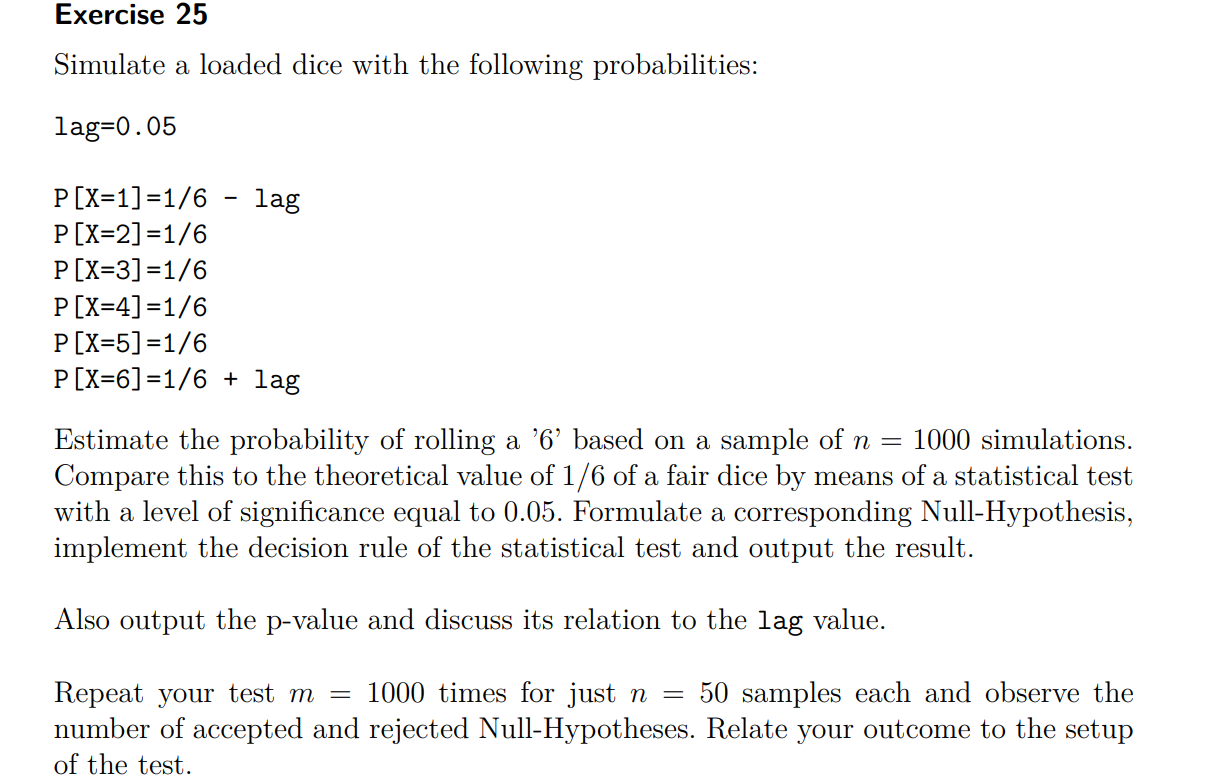

In [13]:
from scipy.stats import binomtest

# Parameter definieren
lag = 0.05
p_fair = 1 / 6
p_loaded = p_fair + lag
probabilities = [p_fair - lag, p_fair, p_fair, p_fair, p_fair, p_loaded]
sides = [1, 2, 3, 4, 5, 6]

alpha = 0.05
n = 1000

# 1. Würfelwürfe simulieren
np.random.seed(42)  # Für Reproduzierbarkeit
rolls = np.random.choice(sides, size=n, p=probabilities)

# 2. Anzahl und relative Häufigkeit der '6' berechnen
k_sixes = np.sum(rolls == 6)
p_estimated = k_sixes / n

print(f"--- Teil 1: n = {n} Simulationen ---")
print(f"Gewürfelte Sechsen: {k_sixes} von {n}")
print(f"Geschätzte Wahrscheinlichkeit P[X=6]: {p_estimated:.4f}")
print(f"Theoretische (wahre) Wahrscheinlichkeit: {p_loaded:.4f}")

# 3. Binomialtest durchführen
# Erwartet unter H0: p = 1/6
test_result = binomtest(k_sixes, n=n, p=p_fair, alternative='two-sided')
p_value = test_result.pvalue

print(f"p-Wert des Tests: {p_value:.5f}")

# 4. Entscheidungsregel
if p_value < alpha:
    print(f"Ergebnis: H0 wird ABGELEHNT (p < {alpha}). Der Würfel ist signifikant gezinkt.")
else:
    print(f"Ergebnis: H0 wird BEIBEHALTEN (p >= {alpha}). Kein signifikanter Unterschied nachweisbar.")

--- Teil 1: n = 1000 Simulationen ---
Gewürfelte Sechsen: 216 von 1000
Geschätzte Wahrscheinlichkeit P[X=6]: 0.2160
Theoretische (wahre) Wahrscheinlichkeit: 0.2167
p-Wert des Tests: 0.00005
Ergebnis: H0 wird ABGELEHNT (p < 0.05). Der Würfel ist signifikant gezinkt.


## 3. Python-Implementierung (Teil 2: $m = 1000$ Wiederholungen mit $n = 50$)
Jetzt reduzieren wir die Stichprobengröße drastisch auf $n = 50$, wiederholen diesen Test jedoch $m = 1000$ Mal. Wir zählen, wie oft wir fälschlicherweise die $H_0$ beibehalten (obwohl der Würfel gezinkt ist).

In [14]:
m = 1000
n_small = 50

accepted_h0 = 0
rejected_h0 = 0

for _ in range(m):
    # Simuliere 50 Würfe
    rolls_small = np.random.choice(sides, size=n_small, p=probabilities)
    k_sixes_small = np.sum(rolls_small == 6)
    
    # Test durchführen
    p_val_small = binomtest(k_sixes_small, n=n_small, p=p_fair, alternative='two-sided').pvalue
    
    if p_val_small < alpha:
        rejected_h0 += 1
    else:
        accepted_h0 += 1

print("\n--- Teil 2: m = 1000 Wiederholungen mit n = 50 ---")
print(f"Nullhypothese beibehalten (Accepted H0): {accepted_h0} Mal ({accepted_h0/m*100:.1f}%)")
print(f"Nullhypothese abgelehnt (Rejected H0): {rejected_h0} Mal ({rejected_h0/m*100:.1f}%)")


--- Teil 2: m = 1000 Wiederholungen mit n = 50 ---
Nullhypothese beibehalten (Accepted H0): 822 Mal (82.2%)
Nullhypothese abgelehnt (Rejected H0): 178 Mal (17.8%)


#Task 026
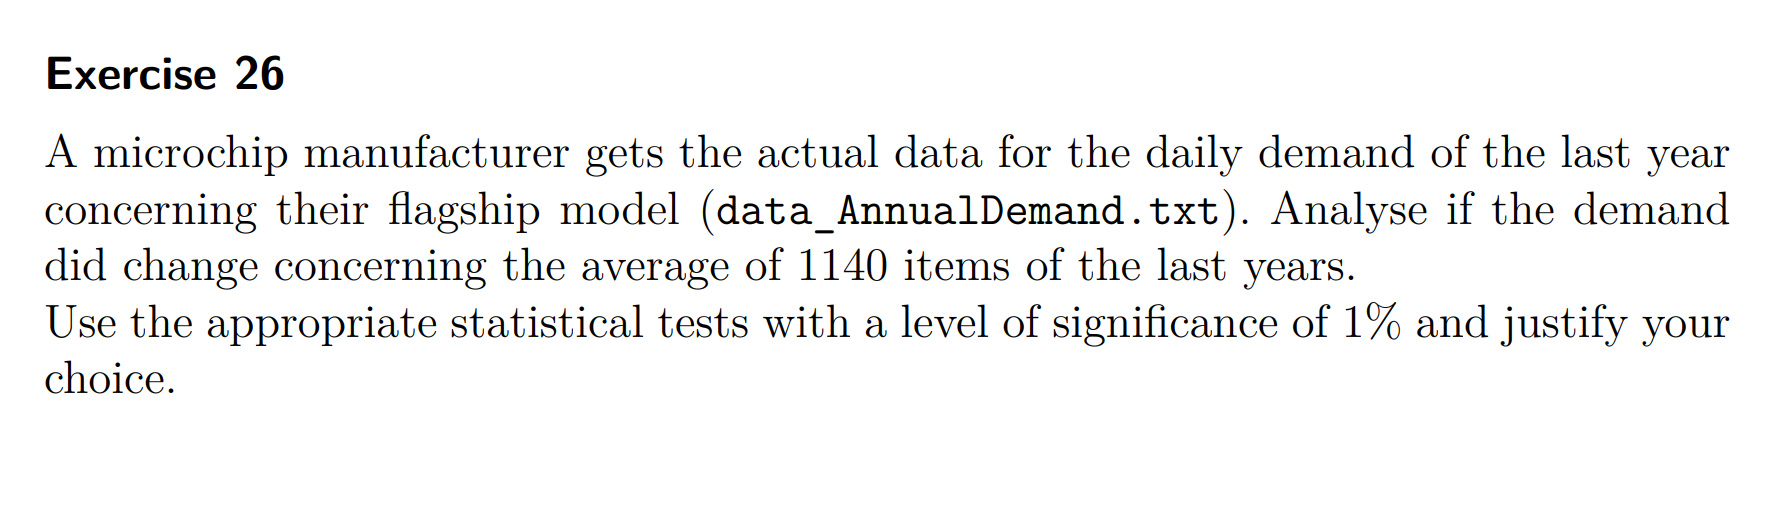

In [18]:
import numpy as np
import scipy.stats as stats

# 1. Daten einlesen
data_path = "data_AnnualDemand.txt"
demand = np.loadtxt(data_path)


# 2. Deskriptive Statistiken berechnen
n = len(demand)
mean_demand = np.mean(demand)
std_demand = np.std(demand, ddof=1)  # Stichprobenstandardabweichung
mu_0 = 1140
alpha = 0.01

print("--- Deskriptive Statistik ---")
print(f"Stichprobengröße (N): {n}")
print(f"Stichprobenmittelwert: {mean_demand:.4f}")
print(f"Standardabweichung: {std_demand:.4f}\n")

print("--- 1. Normalverteilungstest (Shapiro-Wilk) ---")
shapiro_stat, shapiro_p = stats.shapiro(demand)
print(f"Shapiro-Wilk-Statistik: {shapiro_stat:.4f}, p-Wert: {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("Die Daten sind näherungsweise normalverteilt.")
else:
    print("Die Daten weichen signifikant von einer Normalverteilung ab (Zentraler Grenzwertsatz greift dennoch).")

print("\n--- 2. Einstichproben-t-Test ---")
t_stat, t_p = stats.ttest_1samp(demand, mu_0)
print(f"t-Statistik: {t_stat:.4f}")
print(f"p-Wert (zweiseitig): {t_p:.4e}")

# Entscheidung basierend auf dem p-Wert
if t_p < alpha:
    print(f"\nErgebnis: Da der p-Wert ({t_p:.4e}) kleiner als alpha ({alpha}) ist, wird die Nullhypothese ABGELEHNT.")
    print("Der durchschnittliche tägliche Bedarf hat sich signifikant von 1140 Items verändert.")
else:
    print(f"\nErgebnis: Da der p-Wert ({t_p:.4e}) größer oder gleich alpha ({alpha}) ist, wird die Nullhypothese BEIBEHALTEN.")
    print("Es gibt keinen statistisch signifikanten Beleg dafür, dass sich der Bedarf von 1140 Items verändert hat.")

--- Deskriptive Statistik ---
Stichprobengröße (N): 365
Stichprobenmittelwert: 1140.1314
Standardabweichung: 0.7846

--- 1. Normalverteilungstest (Shapiro-Wilk) ---
Shapiro-Wilk-Statistik: 0.9144, p-Wert: 1.5145e-13
Die Daten weichen signifikant von einer Normalverteilung ab (Zentraler Grenzwertsatz greift dennoch).

--- 2. Einstichproben-t-Test ---
t-Statistik: 3.1989
p-Wert (zweiseitig): 1.5004e-03

Ergebnis: Da der p-Wert (1.5004e-03) kleiner als alpha (0.01) ist, wird die Nullhypothese ABGELEHNT.
Der durchschnittliche tägliche Bedarf hat sich signifikant von 1140 Items verändert.
